# Credit Card Fraud Detection

## Business Objective

Develop a machine learning model capable of identifying potentially fraudulent credit card transactions.

The objective is to prioritize suspicious transactions for manual investigation while minimizing financial losses and reducing unnecessary customer friction.

---

## Project Goal

Predict whether a transaction is fraudulent (`Class = 1`) or legitimate (`Class = 0`).

---

## Success Criteria

- High Recall for fraud cases
- Acceptable Precision to avoid excessive false alarms
- Reliable probability estimates for production threshold tuning

In [5]:
import pandas as pd
import numpy as np

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.download_data import download_dataset

In [6]:
dataset_path = download_dataset()

df = pd.read_csv(dataset_path)

Dataset already exists.


In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print(df.shape)

(284807, 31)


In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

The dataset contains anonymized PCA-transformed features (V1–V28), along with Time, Amount, and the target variable Class.

Since the original variables are unavailable, feature interpretation is limited, but predictive modeling remains possible.

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
duplicates = df.duplicated().sum()

duplicates

1081

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [14]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [15]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Observation:

The fraud class represents approximately 0.17% of all transactions, confirming that the dataset is highly imbalanced.

Implication:

Accuracy alone is not an appropriate evaluation metric. Precision, Recall, F1-score, and ROC-AUC will be emphasized.

In [16]:
df.memory_usage(deep=True)

Index         132
Time      2278456
V1        2278456
V2        2278456
V3        2278456
V4        2278456
V5        2278456
V6        2278456
V7        2278456
V8        2278456
V9        2278456
V10       2278456
V11       2278456
V12       2278456
V13       2278456
V14       2278456
V15       2278456
V16       2278456
V17       2278456
V18       2278456
V19       2278456
V20       2278456
V21       2278456
V22       2278456
V23       2278456
V24       2278456
V25       2278456
V26       2278456
V27       2278456
V28       2278456
Amount    2278456
Class     2278456
dtype: int64

#Observations

Facts.

-31 columns
-No missing values
-Highly imbalanced
-Assumptions

Things that haven't verified.

-Each row represents one transaction.
-PCA was performed correctly.
-Risks

Potential issues.

-No transaction ID.
-Duplicate interpretation is uncertain.
-PCA limits interpretability.
-Questions for Stakeholders

Example:

-How were duplicates handled?
-What exactly does Time represent?
-Was PCA fitted using the entire dataset or only the training set?

That last question is incredibly important because it touches on data leakage.

In [17]:
duplicates = df[df.duplicated(keep=False)]

duplicates["Class"].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [18]:
duplicates.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,...,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000
mean,94448.014024,-1.550730,1.043475,-0.443509,0.712007,-0.505289,0.264623,-0.455491,0.311091,0.404644,...,0.048161,-0.028155,-0.050602,-0.056780,0.052956,-0.048344,-0.431845,-0.112888,60.094504,0.017260
std,48781.945109,3.458374,2.335770,2.769019,1.606427,1.970398,1.349820,2.554122,2.985528,1.605576,...,1.876294,0.923816,0.805032,0.610429,0.530623,0.531019,1.221249,0.619060,166.070225,0.130274
min,26.000000,-26.457745,-15.289166,-30.177317,-3.223176,-17.892600,-5.140999,-31.197329,-37.353443,-9.462573,...,-8.755698,-8.887017,-12.476093,-1.735540,-2.888726,-1.408127,-8.878665,-3.713108,0.000000,0.000000
25%,53484.000000,-2.581315,-0.147441,-1.260573,-0.380098,-1.053300,-0.585593,-0.815292,-0.156001,-0.294909,...,-0.280655,-0.493502,-0.212921,-0.405027,-0.218124,-0.434028,-0.398592,-0.146157,6.000000,0.000000
50%,84149.000000,-1.203617,0.872543,0.111028,0.526622,-0.387082,0.015300,-0.220700,0.242394,0.277545,...,-0.041208,-0.029611,-0.013019,0.028883,0.062127,-0.050899,-0.042648,-0.011300,15.980000,0.000000
75%,142583.000000,1.138387,1.938769,1.027314,1.373592,0.435914,0.805797,0.536781,1.131989,0.923278,...,0.211401,0.548888,0.137292,0.409642,0.371655,0.327804,0.053537,0.084515,36.000000,0.000000
max,172233.000000,2.178710,16.497472,3.031897,10.648505,5.834326,6.584992,8.300058,9.673941,7.938980,...,27.202839,3.460893,5.303607,1.182948,2.721087,1.833597,2.340472,2.285113,1848.060000,1.000000


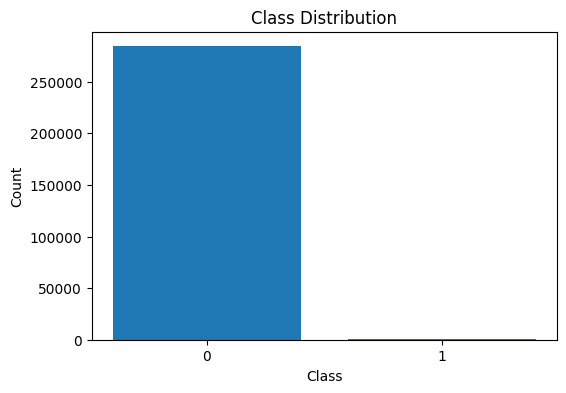

In [19]:
# Does the transaction amount differ between fraud and non-fraud?
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

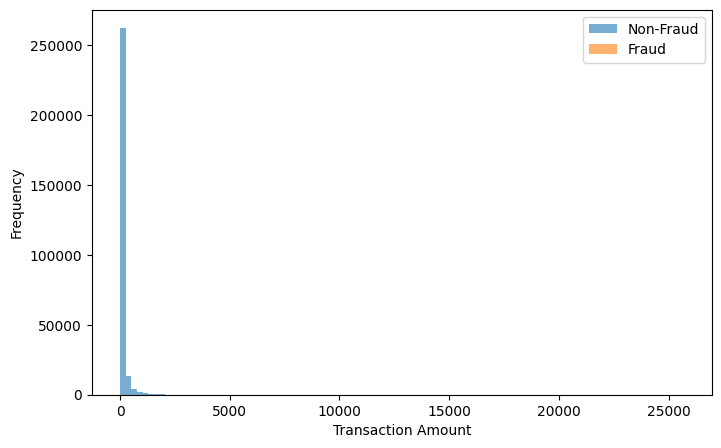

In [20]:
# Do fraudulent transactions have different transaction amounts?

plt.figure(figsize=(8,5))

plt.hist(
    df[df["Class"] == 0]["Amount"],
    bins=100,
    alpha=0.6,
    label="Non-Fraud"
)

plt.hist(
    df[df["Class"] == 1]["Amount"],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.legend()
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [21]:
# Which variables have the strongest relationship with fraud?
corr = df.corr(numeric_only=True)

corr["Class"].sort_values(ascending=False)



Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Correlation only measures Linear relationship Nothing more.

No feature exhibits a strong linear correlation with the target variable. This does not imply that the features are uninformative, as non-linear models may still capture predictive relationships.
##### Observation 1
None of the individual variables shows a strong linear relationship with fraud. This suggests that fraudulent behavior is likely driven by combinations of features rather than any single attribute.

###### Observation 2
Fraud represents less than 1% of all transactions. Therefore, a model that predicts every transaction as legitimate would achieve very high accuracy while completely failing to detect fraud. This makes accuracy an unsuitable evaluation metric

<Figure size 1000x600 with 0 Axes>

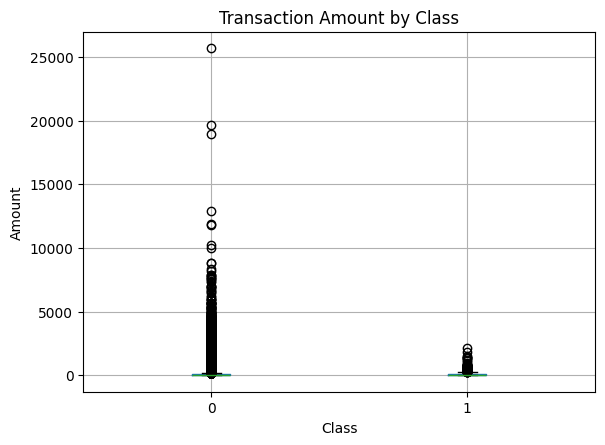

In [23]:
# box plot for transaction amount by class
plt.figure(figsize=(10,6))

df.boxplot(column="Amount", by="Class")

plt.title("Transaction Amount by Class")
plt.suptitle("")

plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

In [24]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


###### Observation
Median : Fraud = 9.25 , Non Fraud = 22 
A typical fraudulent transaction is smaller than a typical legitimate transaction.
Fraudsters often perform small "card testing" transactions before making larger purchases.


transaction amount alone does not sufficiently distinguish fraudulent and legitimate transactions. Although fraudulent transactions have a lower median amount, there is substantial overlap between the two distributions. A rule based solely on amount would generate a large number of false positives by incorrectly flagging many genuine transactions, while also missing fraud occurring at other amounts. Instead, transaction amount should be used as one predictive feature alongside other variables in a machine learning model.

In [25]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [26]:
df['Time'].value_counts()

Time
163152.0    36
64947.0     26
68780.0     25
3767.0      21
3770.0      20
            ..
127750.0     1
62260.0      1
62259.0      1
127753.0     1
172792.0     1
Name: count, Length: 124592, dtype: int64

# Investigation 1

## Business Question

Do fraudulent transactions have significantly different transaction amounts compared to legitimate transactions?

---

## Why does this matter?

If transaction amounts differ significantly, then the Amount feature may provide predictive information for fraud detection.

However, statistical significance alone does not guarantee that Amount is sufficient for classification.

H₀

Fraud and Non-Fraud transactions have the same distribution of Amount.

H₁

Fraud and Non-Fraud transactions have different distributions.



 Mann–Whitney Test is a non-parametric test that can be used to compare two independent samples. It is often used when the assumptions of the t-test are not met, such as when the data is not normally distributed or when the sample sizes are small.

In [28]:
from scipy.stats import mannwhitneyu

fraud_amount = df[df["Class"] == 1]["Amount"]

nonfraud_amount = df[df["Class"] == 0]["Amount"]

statistic, p_value = mannwhitneyu(
    fraud_amount,
    nonfraud_amount,
    alternative="two-sided"
)

print(statistic)
print(p_value)

61833399.0
8.57847231084022e-06


Statistical Test

Test Used: Mann–Whitney U Test

Reason:

Comparing two independent groups.
Amount is continuous.
Distribution is highly skewed with many outliers.
Therefore a non-parametric test is appropriate.

Hypotheses: 
H₀:
The distribution of transaction amounts is the same for fraud and non-fraud.

H₁:
The distributions are different.

Statistic = 61833399

p-value = 8.57 × 10⁻⁶
Since  : p-value < 0.05

Observation : 
The transaction amount distributions differ statistically between fraudulent and legitimate transactions. However, there is considerable overlap between the two distributions. Therefore, transaction amount alone is unlikely to be sufficient for fraud detection but should be used as one of several predictive features.